# Stock Investment Notebook - CS4650 Project #4

## Week #2 - Long short-term memory (LSTM)

Refrence: https://www.analyticsvidhya.com/blog/2021/03/introduction-to-long-short-term-memory-lstm/

Using this method, i intent to use 25% of the initial 250,000 for investing into said stocks. 25% will be distributed between 10 stocks and percent will be allocated evenly between the 5 chosen stock. This model will use the "recurent neural network called Long Short Term Memory (LSTM)" to build the forecast. It will use the last 60 days for this.

In [73]:
#import libraries
import yfinance as yf
import yahoofinancials
import math 
import pandas as pd 
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

In [74]:
AAPL = yf.download('SPY', 
                      start='2015-01-01', 
                      end='2022-01-01', 
                      progress=False)
AAPL

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2015-01-02,206.380005,206.880005,204.179993,205.429993,180.976227,121465900
2015-01-05,204.169998,204.369995,201.350006,201.720001,177.707886,169632600
2015-01-06,202.089996,202.720001,198.860001,199.820007,176.034058,209151400
2015-01-07,201.419998,202.720001,200.880005,202.309998,178.227631,125346700
2015-01-08,204.009995,206.160004,203.990005,205.899994,181.390259,147217800
...,...,...,...,...,...,...
2021-11-17,469.000000,469.190002,467.480011,468.140015,468.140015,47858300
2021-11-18,469.239990,470.010010,466.339996,469.730011,469.730011,50625600
2021-11-19,469.609985,470.940002,468.500000,468.890015,468.890015,57288900


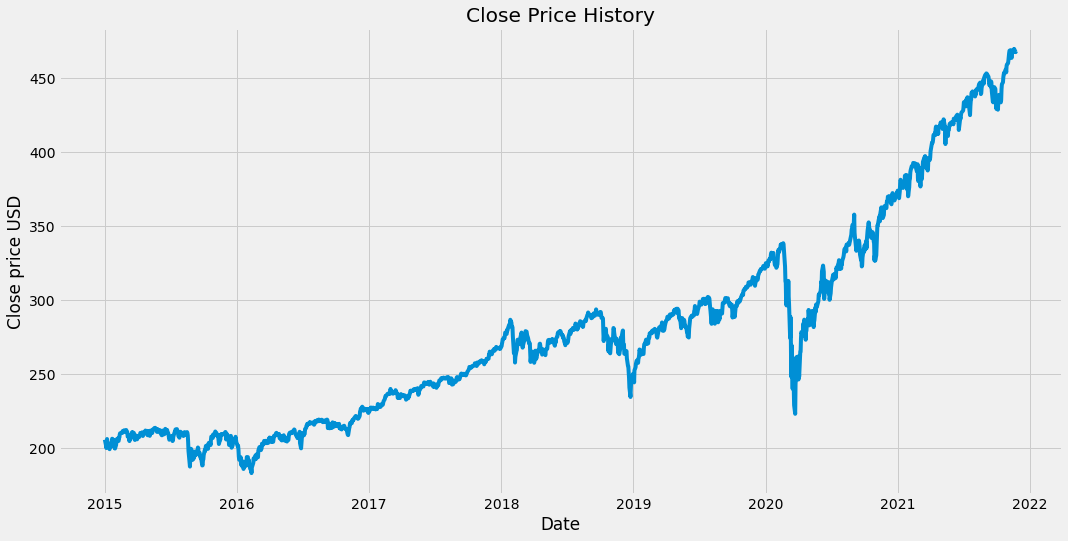

In [75]:
plt.figure(figsize = (16,8))
plt.title('Close Price History')
plt.plot(AAPL['Close'])
plt.xlabel('Date')
plt.ylabel('Close price USD')
plt.show()

In [76]:
# Create a new dataframe with only a column "Close"
data = AAPL.filter(['Close'])

# convert to numpaev array
dataset = data.values

# pulls out the number of rows in the date for training the model (LSTM)
training_data_len = math.ceil(len(dataset) * .8)
training_data_len

1390

In [77]:
# Scale the data (scalable)
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(dataset) 
scaled_data

array([[0.07867672],
       [0.06574407],
       [0.05912088],
       ...,
       [0.99707186],
       [0.99247044],
       [0.99463169]])

In [78]:
# Create a dataset for training
train_data = scaled_data[0:training_data_len]

# split into x underscore train and underscore train 
x_train = []
y_train = []

for i in range(60, len(train_data)):
    x_train.append(train_data[i-60:i])
    y_train.append(train_data[i])

In [79]:
# Convert x_train and y_train to numpy array
x_train, y_train = np.array(x_train), np.array(y_train)

In [80]:
# Reshape data
x_train = np.reshape(x_train, (x_train.shape[0],x_train.shape[1],x_train.shape[2]))

In [81]:
# Building the neuron
model = Sequential()
model.add(LSTM(50,return_sequences = True, input_shape = (x_train.shape[1],x_train.shape[2])))
model.add(LSTM(50,return_sequences = False))
model.add(Dense(25))
model.add(Dense(1))

In [82]:
# Compile the model
model.compile(optimizer='adam',loss = 'mean_squared_error')

# Train the model

In [83]:
# Train the model
model.fit(x_train,y_train,batch_size = 1, epochs = 10)

Epoch 1/10
1330/1330 [==============================] - 17s 11ms/step - loss: 0.0010
Epoch 2/10
1330/1330 [==============================] - 15s 11ms/step - loss: 4.3059e-04
Epoch 3/10
1330/1330 [==============================] - 15s 11ms/step - loss: 3.0461e-04 1s
Epoch 4/10
1330/1330 [==============================] - 15s 11ms/step - loss: 3.1161e-04
Epoch 5/10
1330/1330 [==============================] - 15s 11ms/step - loss: 2.4435e-04
Epoch 6/10
1330/1330 [==============================] - 15s 11ms/step - loss: 2.2505e-04
Epoch 7/10
1330/1330 [==============================] - 15s 11ms/step - loss: 2.0289e-04
Epoch 8/10
1330/1330 [==============================] - 15s 11ms/step - loss: 2.0753e-04
Epoch 9/10
1330/1330 [==============================] - 15s 11ms/step - loss: 2.1063e-04 0s - loss:
Epoch 10/10
1330/1330 [==============================] - 15s 11ms/step - loss: 2.1686e-04


In [84]:
# Create a test dataset
test_data = scaled_data[training_data_len - 60:]

# by analogy, create x_test and y_test
x_test = []
y_test = dataset[training_data_len:]
for i in range(60,len(test_data)):
    x_test.append(test_data[i-60:i])

In [85]:
# again transform into a numpy array
x_test = np.array(x_test)

In [86]:
# reshape again
x_test = np.reshape(x_test,(x_test.shape[0],x_test.shape[1],x_test.shape[2]))

In [87]:
# Getting a model predicting values
predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)

In [88]:
# Get mean squared error (RMSE) - least squares method
rmse =np.sqrt(np.mean(predictions-y_test)**2)
rmse

0.6337296103881485

# Visualize

C:\Users\Public\Documents\Wondershare\CreatorTemp/ipykernel_4084/613305967.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions'] = predictions


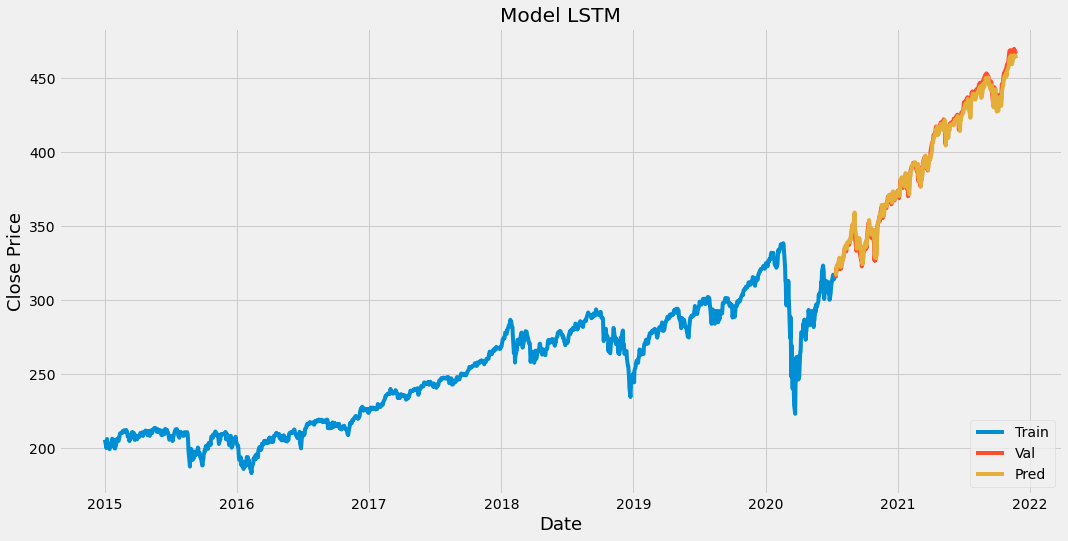

In [89]:
# build a schedule
train = data[:training_data_len]
valid = data[training_data_len: ]
valid['Predictions'] = predictions

# visualize
plt.figure(figsize=(16,8))
plt.title('Model LSTM')
plt.xlabel('Date', fontsize = 18)
plt.ylabel('Close Price',fontsize = 18)
plt.plot(train['Close'])
plt.plot(valid[['Close','Predictions']])
plt.legend(['Train','Val','Pred'], loc = 'lower right')
plt.show()

# Week #2 Trade Exeucutions:

Week #2: Starting funds as of 11/12: $250853.01

Given these results, money in each stock was allocated as such:

[Incert Image]

Total Funds Allocated: $62,998.71

Performance History:

[Incert Image]

In [ ]:
#Week 2 Funds
week2start = 250853.01
week2end = ?


#Week 2 starting funds
print("Week #1 starting funds as of 11/19: ${}".format(week1start))

#Week 2 ending funds
print("Week #1 ending funds as of 11/19: ${}".format(week2end))

# Percent gain/loss
percentDiffrence = ((week1start - week2end)/((week1start + week2end)/2))*-100
print("Week #1 percent gain/loss was: +{}%".format(percentDiffrence))

#Profit
gain_loss = week2end - week1start
print("Week #1 profit as of 11/19: ${}".format(gain_loss))

SPY
SSgA Active Trust - S&P 500 ETF TRUST ETF
Buy at Market Open
27
$468.19


GME
Gamestop Corporation - Ordinary Shares - Class A
Buy at Market Open
59
$213.90


ZM
Zoom Video Communications Inc - Ordinary Shares - Class A
Buy at Market Open
60
$206.64


MU
Micron Technology Inc.
Buy at Market Open
148
$85.41


NVDA
NVIDIA Corp
Buy at Market Open
40
$317.46

# Week#3 - Soon.....